<a href="https://colab.research.google.com/github/zastrozhnayayana/nn-zero-to-hero-notes/blob/main/04_makemore_batchnorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-05-13 13:43:22--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.1’

names.txt.1         100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-05-13 13:43:22 (8.69 MB/s) - ‘names.txt.1’ saved [228145/228145]



In [ ]:
stoi = {chr(i): i - ord('a') + 1 for i in range(ord('a'), ord('z') + 1)} # 'a' -> 1 ... '.' -> 0
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [ ]:
# words = open('names.txt').read() # читает всё в одну строку (в том числе в ней есть '\n')
words = open('names.txt').read().splitlines() # массив из строк

In [ ]:
X, Y = [], []

block_size = 3 # 3 последних символа рассматриваем, предсказываем 4ый
n_emb = 10 # каждую букву шифрую вектором размерности 10
vocab_size = 27
n_hidden = 100 # кол-во нейронов в скрытом слое

for w in words:
  context = [0] * block_size
  for lt in w + '.':
    X.append(context)
    Y.append(stoi[lt])
    context = context[1:] + [stoi[lt]]

X = torch.tensor(X) # примеры. каждый пример это номера трёх предыдущих букв
Y = torch.tensor(Y) # ответ на соответствующий пример

In [ ]:
C = torch.randn((vocab_size, n_emb)) # С[lt] = в какой 10-мерный вектор переходит буква lt
C.shape

torch.Size([27, 10])

In [ ]:
emb = C[X] # выбираю строки С по индексам из Х. просто заменила каждый номер буквы на 10-мерный вектор
emb = emb.view(emb.shape[0], n_emb * block_size) # запиши всё в один массив, а потом попили таким образом
# 228146 примеров, каждый пример теперь это 30 чисел (3 10-мерных вектора соотв буквам записали подряд)
# хотим умножать двумерные тензоры
emb.shape

torch.Size([228146, 30])

In [ ]:
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)

Xtr, Ytr = X[:n1], Y[:n1]
Xdev, Ydev = X[n1:n2], Y[n1:n2]
Xte, Yte = X[n2:], Y[n2:]

In [ ]:
# когда мы применяем линейный слой, распределение на выходе увеличивается в несколько раз
# для этого делим на корень из fan_in (кол-во входных данных у 1 нейрона)
# tanh ещё сожмёт наши данные, поэтому нужен коэффициент 5 / 3, чтобы их обратно разжать
# наша цель, чтобы стандартное отклонение оставалось примерно одинаковым, адекватным
# чтобы tanh не взрывался (будет std = 1, потом = 3, потом = 9...)
W1 = torch.randn((n_emb * block_size, n_hidden)) * (5/3) / ((n_emb * block_size) ** 0.5) # 100 нейронов в скрытом слое. у каждого 30 входных данных и соответственно 30 весов
#b1 = torch.randn(n_hidden) * 0.01
W2 = torch.randn((n_hidden, vocab_size)) * 0.01 # хотим теперь для каждого примера по выходам 100 нейронов понять какая буква будет следующей (по предположению модели)
# 26 вероятностей каждой буквы
b2 = torch.randn(vocab_size) * 0

#batchnorm layer parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
#buffers
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

params = [W1, W2, b2, bngain, bnbias]

for p in params:
  p.requires_grad = True # листья по умолчанию без градиента в pytorch

In [ ]:
max_steps = 200000
batch_size = 32

for k in range(max_steps):
  #выбрала случайную группу из примеров
  X, Y = Xtr, Ytr
  ix = torch.randint(0, X.shape[0], (batch_size,)) # в каком интервале значения, какой размер
  emb = C[X[ix]].view(-1, n_emb * block_size)

  #forward pass
  hpreact = emb @ W1 # + b1 # для каждого примера (из батча) выходы всех нейронов

  #batchnorm layer
  # хотим чтобы значения, которые мы скармливаем в tanh имели mean = 0, std = 1
  # чтобы tanh не выдавал всегда просто -1 или 1 из-за точности вычислений (скармливаем слишком большие по модулю числа)
  # тогда эти нейроны перестают пропускать через себя градиент или наоборот просто пропускают его, не добавляя новой информации
  # такие нейроны бесполезные, не хотим занимать ими память и тратить на них время
  # сделать распределение стандартизованным - просто один из способов привести значения к такому виду, что tanh не будет насыщенным
  # хотим, чтобы распределение было стандартизованным только на инициализации, потому что не хотим ограничивать сеть в дальнейшем
  # используем bngain и bnbias - масштаб и сдвиг распределения, которое мы скармливаем в tanh
  #-----------------------------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim = True)
  bnstdi = hpreact.std(0, keepdim = True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  # в конце при тестировании нашей сети, нам нужно будет скармливать в неё один пример
  # а сейчас у нас вычисляется среднее по батчу
  # давай просто возьмём среднее и стандартное отклонение, которые у нас получались при обучении и будем использовать их при тестировании
  # можем поддерживать буффер, чтобы в конце отдельно не считать (будет примерно то же значение)

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  #-----------------------------------------------------------------------------------
  h = torch.tanh(hpreact) # нелинейность
  logits = h @ W2 + b2 # для каждого примера распределение вероятностей следующей буквы
  loss = F.cross_entropy(logits, Y[ix]) # считаем ошибку
  """
  Softmax:
  counts = logits.exp()
  probs = logits.sum(1, keepdim = True)
  loss = -prob[torch.arange(32), Y].log().mean()
  """

  #backward pass
  for p in params:
    p.grad = None

  loss.backward()

  #update
  for p in params:
    p.data += -0.1 * p.grad
  if k % 10000 == 0:
    print(loss.item())

3.307508707046509
1.7568520307540894
1.8399617671966553
2.0573182106018066
1.751683235168457
1.9384583234786987
1.7500300407409668
1.671684980392456
2.0716452598571777
2.252755641937256
1.7129542827606201
2.1947782039642334
1.6167147159576416
2.186720371246338
1.477594017982483
2.310786485671997
1.5833351612091064
1.9361099004745483
2.1320512294769287
1.553818941116333


In [ ]:
C[X].shape

torch.Size([25626, 3, 10])

In [ ]:
with torch.no_grad():
  emb = C[Xtr]
  hpreact = emb.view(-1, n_emb * block_size) @ W1 #+ b1
  bnmean = hpreact.mean(0, keepdim = True);
  bnstd = hpreact.std(0, keepdim = True)
print(bnmean, bnstd)
print(bnmean_running, bnstd_running)

tensor([[-0.5419, -4.9382, -0.2732,  1.6598,  0.5919,  2.4227, -0.4526,  0.4051,
         -2.6408, -3.9161, -0.7550,  0.7769, -2.0475, -2.3827, -0.7851,  1.6111,
          0.2103,  2.0665,  2.3258,  0.8544,  0.8792,  1.3855,  0.9447, -0.6379,
         -1.8640, -0.8044,  2.0520, -1.4924,  3.0676, -0.8170,  0.2012,  0.8191,
          0.6157,  0.6007,  1.4059,  1.0612,  1.9750, -3.8721,  0.4745,  0.9787,
         -1.2808,  1.9604, -0.1475, -1.4452, -1.4913, -1.8066, -1.5025, -1.4174,
         -0.6603, -0.1241,  1.5501,  0.2564,  0.6462, -0.0300,  1.4684,  0.2767,
          0.0694, -2.3745, -2.8510, -0.4387,  0.4366,  1.7754,  1.6920, -0.6565,
          0.0625, -3.0106,  0.4687,  2.7217, -1.5230, -2.0830,  2.4057, -0.0380,
         -1.3011, -1.8939, -3.8067, -1.5879, -2.9701, -0.9348, -0.2457, -0.1437,
         -1.0600, -2.9104, -1.9260,  2.3934,  0.8109, -0.0902,  0.9910,  1.7997,
          1.0776,  0.2987,  1.9088,  0.8931, -2.0602,  0.6655, -0.3928,  2.6373,
          0.0327,  0.6801,  

In [ ]:
@torch.no_grad()
def split_loss(X, Y):
  emb = C[X]
  hpreact = emb.view(-1, n_emb * block_size) @ W1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)
  return loss

print(split_loss(Xtr, Ytr))
print(split_loss(Xdev, Ydev))

tensor(1.7813)
tensor(2.0856)


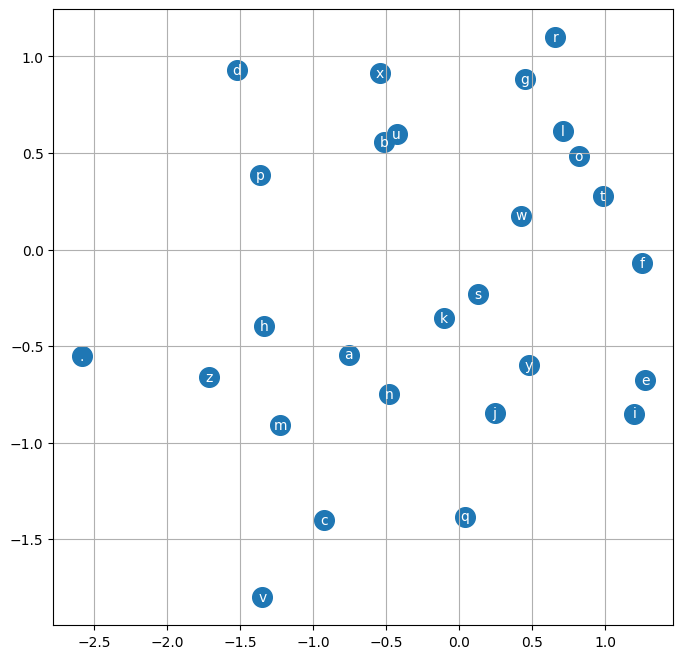

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
for i in range(20):
  context = [0] * block_size
  ans = ""
  while True:
    hpreact = C[context].view(n_emb * block_size) @ W1
    hpreact = bngain * (hpreact - bnmean) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    probs = F.softmax(logits)

    ix = torch.multinomial(probs, num_samples=1).item()
    if ix == 0:
      break
    ans += itos[ix]
    context = context[1:] + [ix]
  print(ans)

nicttie
camer
ber
liza
lyn
vey
vamilla
kiyah
ches
raqke
kayla
lynn
elle
dessn
viern
cassa
lille
addilynn
riellyanna
cia


/tmp/ipykernel_16466/1887194958.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(logits)
